In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [4]:
train_df = pd.read_csv("GiveMeSomeCredit/cs-training.csv")
test_df  = pd.read_csv("GiveMeSomeCredit/cs-test.csv")

print(train_df.shape, test_df.shape)

(150000, 12) (101503, 12)


In [5]:
train_df.drop(columns=["Unnamed: 0"], inplace=True)
test_df.drop(columns=["Unnamed: 0"], inplace=True)

In [6]:
df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
df.shape

(251503, 11)

In [7]:
df.fillna(df.median(), inplace=True)

In [8]:
X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,          # 30 out of 150 → 120:30
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (201202, 10)
Test : (50301, 10)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [11]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [12]:
log_reg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

cv_scores = cross_val_score(
    log_reg,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="f1"
)

print("LogReg CV F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

LogReg CV F1 scores: [0.15128317 0.14474629 0.14201135]
Mean CV F1: 0.14601360344059314


In [13]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

cv_scores = cross_val_score(
    rf,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="f1"
)

print("RF CV F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

RF CV F1 scores: [0.22953748 0.23136985 0.23406114]
Mean CV F1: 0.2316561566306143


In [16]:
from sklearn.model_selection import GridSearchCV

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

xgb_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
    "min_child_weight": [5, 10]
}

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring="roc_auc",   # 🔥 correct metric
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_scaled, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best XGBoost params:")
print(grid_xgb.best_params_)

Fitting 3 folds for each of 96 candidates, totalling 288 fits


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:11:12] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1770963550200/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:11:12] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1770963550200/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:11:12] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1770963550200/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:11:12] WARNING: /Users/runner/miniforge3/conda-bld/x

Best XGBoost params:
{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.8}


In [17]:
from sklearn.metrics import roc_auc_score, classification_report

y_test_pred = best_xgb.predict(X_test_scaled)
y_test_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1 Score :", f1_score(y_test, y_test_pred))
print("Test ROC-AUC  :", roc_auc_score(y_test, y_test_prob))

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

Test Accuracy: 0.9601001968151727
Test F1 Score : 0.029966167230546157
Test ROC-AUC  : 0.8574129784450586

Classification Report:

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98     48296
         1.0       0.48      0.02      0.03      2005

    accuracy                           0.96     50301
   macro avg       0.72      0.51      0.50     50301
weighted avg       0.94      0.96      0.94     50301



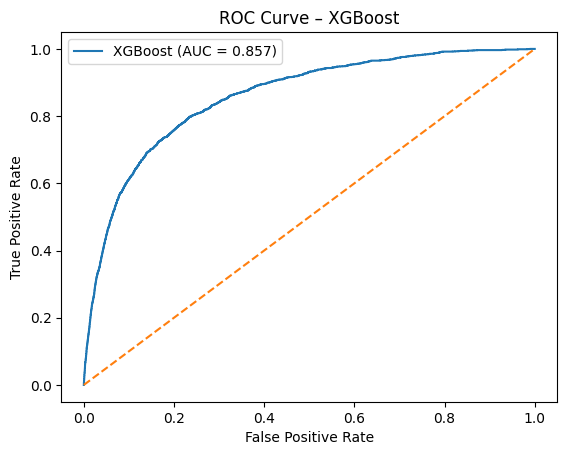

In [18]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure()
plt.plot(fpr, tpr, label="XGBoost (AUC = %.3f)" % roc_auc_score(y_test, y_test_prob))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend()
plt.show()

In [19]:
import shap

# Use a small background sample for speed
background = X_train_scaled[np.random.choice(
    X_train_scaled.shape[0],
    size=1000,
    replace=False
)]

explainer = shap.TreeExplainer(best_xgb, background)
shap_values = explainer.shap_values(X_test_scaled)

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|===================| 50296/50301 [04:33<00:00]        

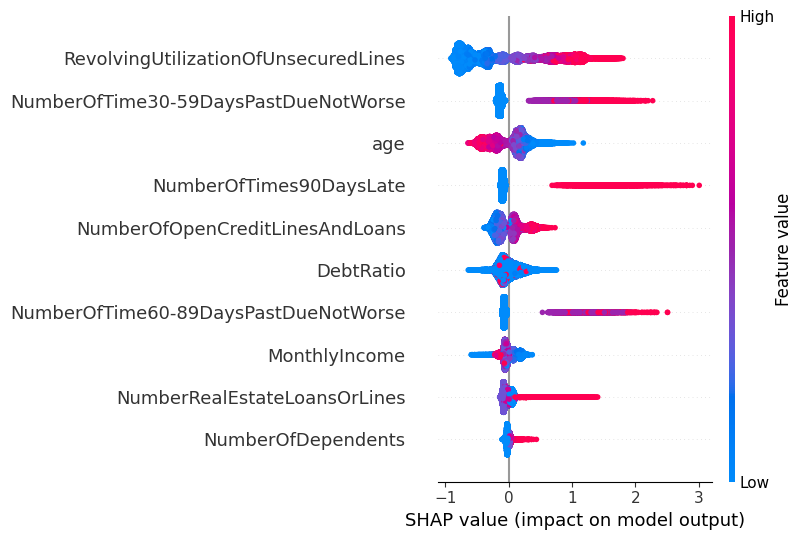

In [20]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

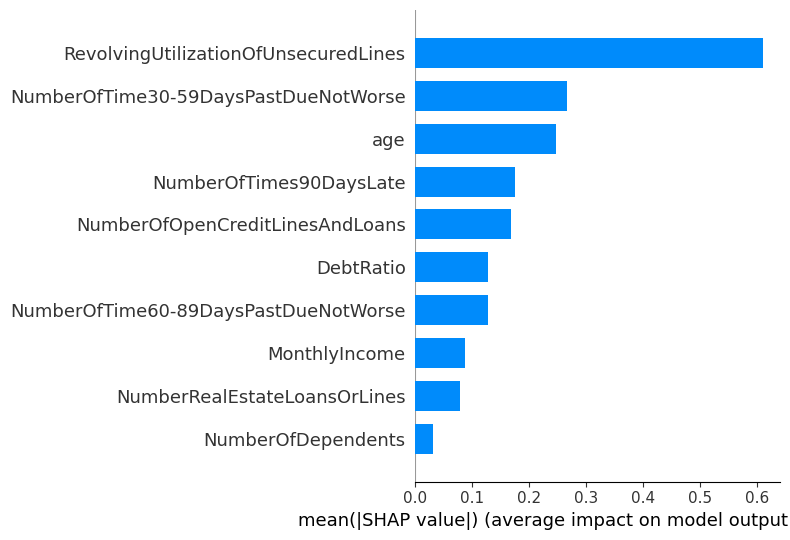

In [21]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar"
)